In [1]:
import sys
import os

sys.path.append(os.path.abspath("../"))

from src.data_loader import load_data
import pandas as pd

data_path = "../data/customer_churn_data.csv"

In [7]:
df = load_data(data_path)
df.head(15)

avoid_column = ["customerID", "tenure","TotalCharges","Contract", "MonthlyCharges"]

for column in df.columns:
    if column in avoid_column:
        continue
    print(f"column name: {column}, values: {df[column].unique()}")

column name: gender, values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
column name: SeniorCitizen, values: [0 1]
column name: Partner, values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
column name: Dependents, values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
column name: PhoneService, values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
column name: MultipleLines, values: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
column name: InternetService, values: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
column name: OnlineSecurity, values: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: OnlineBackup, values: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
column name: DeviceProtection, values: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: TechSupport, values: <StringArray>
['No', 'Yes', 'No internet service']
Le

In [3]:
df["TotalCharges"].str.strip().eq("").sum() 

np.int64(11)

In [4]:
df[
    df["TotalCharges"].str.strip() == ""
][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [5]:
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
churn_rate = round(len(df[df["Churn"]=="Yes"]) / len(df) * 100 , 2)
print(churn_rate)

26.54


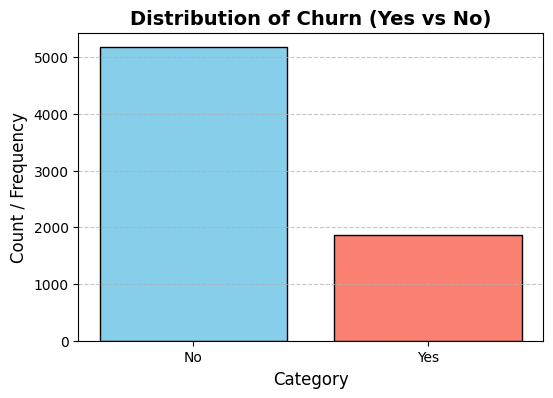

In [7]:
import matplotlib.pyplot as plt

count = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(count.index, count.values, color = ["skyblue", "salmon"], edgecolor = "black")
plt.title("Distribution of Churn (Yes vs No)", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Contract vs Churn Percentage

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Visualize Contract Vs Churn

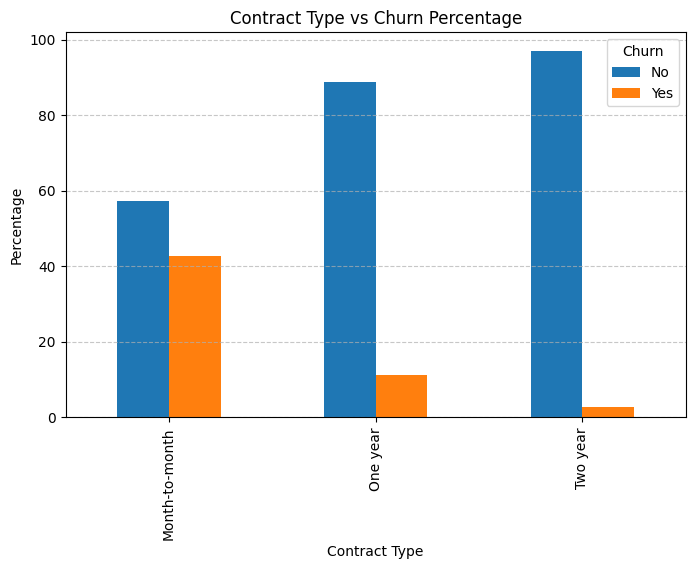

In [9]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Contract Type vs Churn Percentage")
plt.ylabel("Percentage")
plt.xlabel("Contract Type")
plt.legend(title="Churn")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Average Tenure Comparison

In [10]:
df.groupby("Churn")["tenure"].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

### Visualize Tenure

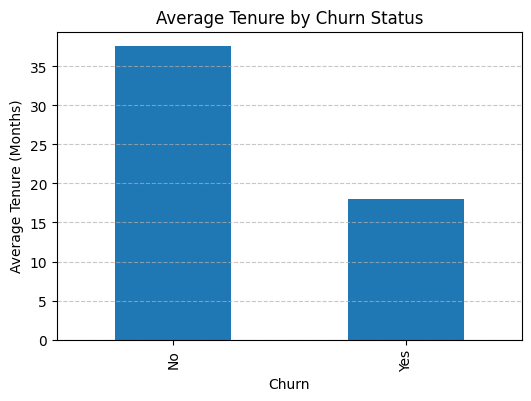

In [11]:
avg_tenure = df.groupby("Churn")["tenure"].mean()

avg_tenure.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Tenure by Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.xlabel("Churn")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Average Monthly Charges Comparison

In [12]:
df.groupby("Churn")["MonthlyCharges"].mean().round(2)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

### Visualize Monthly charges

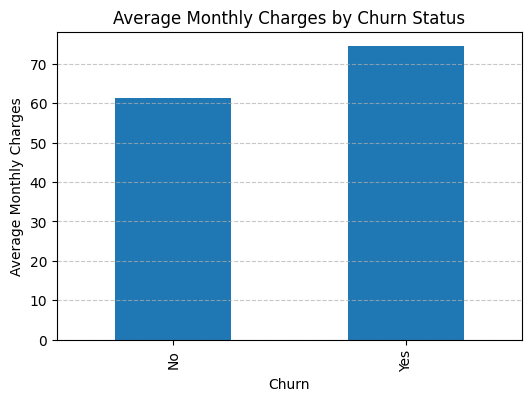

In [13]:
avg_monthly = df.groupby("Churn")["MonthlyCharges"].mean()

avg_monthly.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Monthly Charges by Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xlabel("Churn")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Gender Vs Churn

In [14]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
)

gender_churn.round(2)

Churn,No,Yes
gender,,
Female,0.73,0.27
Male,0.74,0.26


### Partner Vs Churn

In [15]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize = "index"
)

partner_churn.round(2)

Churn,No,Yes
Partner,,
No,0.67,0.33
Yes,0.80,0.20


### Dependents Vs Churn

In [16]:
dependent_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize= "index"
)

dependent_churn.round(2)

Churn,No,Yes
Dependents,,
No,0.69,0.31
Yes,0.85,0.15


### Internet Service Vs Churn

In [17]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize = "index"
)

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,0.81,0.19
Fiber optic,0.58,0.42
No,0.93,0.07
